# LAB 02 — N-GRAM LANGUAGE MODELS, SMOOTHING AND PERPLEXITY

**Môn học:** Xử lý ngôn ngữ tự nhiên và ứng dụng  
**Học kỳ:** I - 2026  
**Giảng viên / TA:** Phạm Ngọc Hải  

Notebook này thực thi toàn bộ các thực nghiệm theo yêu cầu của **W2.pdf**:
- **Experiment 1:** Thống kê ngữ liệu C4 và phân tích phân phối Zipf của Unigram, Bigram, Trigram.
- **Experiment 2 & 3:** So sánh mô hình MLE vs Laplace Smoothing và khảo sát Perplexity trên tập Train, Validation, Test.
- **Application 1:** Hệ thống dự đoán từ tiếp theo (Next-Word Prediction).
- **Application 2:** Xếp hạng các câu ứng viên (Sentence Ranking) bằng xác suất chuỗi và điểm số chuẩn hóa.
- **Context Length Experiment:** Khảo sát hiện tượng thưa thớt dữ liệu (Sparsity) và tỷ lệ n-gram chưa từng thấy (Unseen N-grams).

In [1]:
import gzip
import json
import math
import re
import time
from collections import Counter
import matplotlib.pyplot as plt
import pandas as pd
from ngram_lm import (
    NGramLanguageModel,
    build_vocabulary,
    count_ngrams,
    tokenize,
    run_unit_tests
)
run_unit_tests()

ALL UNIT TESTS PASSED SUCCESSFULLY!


## 1. Nạp và tiền xử lý tập ngữ liệu C4 (10K Documents)

In [2]:
raw_docs = []
with gzip.open("dataset/c4-train.00000-of-01024-30K.json.gz", "rt", encoding="utf-8") as f:
    for i, line in enumerate(f):
        if i >= 10000:
            break
        raw_docs.append(json.loads(line)["text"])

all_sentences = []
for doc in raw_docs:
    for s in re.split(r"[\n.!?]+", doc):
        s = s.strip()
        if 4 <= len(s.split()) <= 25:
            all_sentences.append(s)
            if len(all_sentences) >= 25000:
                break
    if len(all_sentences) >= 25000:
        break

train_sentences = all_sentences[:16000]
val_sentences = all_sentences[16000:18000]
test_sentences = all_sentences[18000:20000]
eval_train = train_sentences[:500]
eval_val = val_sentences[:500]
eval_test = test_sentences[:500]

print("Loaded documents:", len(raw_docs))
print("Total extracted sentences:", len(all_sentences))
print("Train sentences:", len(train_sentences))
print("Validation sentences:", len(val_sentences))
print("Test sentences:", len(test_sentences))

Loaded documents: 10000
Total extracted sentences: 25000
Train sentences: 16000
Validation sentences: 2000
Test sentences: 2000


## 2. Experiment 1 — Thống kê Ngữ liệu & Phân phối Tần số N-gram (Mục 13)

In [3]:
tokenized_train = [tokenize(s) for s in train_sentences]
flat_tokens = [tok for s in tokenized_train for tok in s]

unigram_counter = Counter(flat_tokens)
bigram_counter = Counter()
trigram_counter = Counter()

for s in tokenized_train:
    if len(s) >= 2:
        for i in range(len(s) - 1):
            bigram_counter[(s[i], s[i+1])] += 1
    if len(s) >= 3:
        for i in range(len(s) - 2):
            trigram_counter[(s[i], s[i+1], s[i+2])] += 1

num_unique_u = len(unigram_counter)
num_unique_b = len(bigram_counter)
num_unique_t = len(trigram_counter)

single_u = sum(1 for c in unigram_counter.values() if c == 1)
single_b = sum(1 for c in bigram_counter.values() if c == 1)
single_t = sum(1 for c in trigram_counter.values() if c == 1)

stats_data = [
    {"Model / Level": "Unigram", "Unique N-grams Count": num_unique_u, "Singletons Count": single_u, "Singleton %": f"{single_u / num_unique_u * 100:.2f}%"},
    {"Model / Level": "Bigram", "Unique N-grams Count": num_unique_b, "Singletons Count": single_b, "Singleton %": f"{single_b / num_unique_b * 100:.2f}%"},
    {"Model / Level": "Trigram", "Unique N-grams Count": num_unique_t, "Singletons Count": single_t, "Singleton %": f"{single_t / num_unique_t * 100:.2f}%"}
]

df_stats = pd.DataFrame(stats_data)
display(df_stats)

,Model / Level,Unique N-grams Count,Singletons Count,Singleton %
0,Unigram,20684,9686,46.83%
1,Bigram,118139,94880,80.31%
2,Trigram,168648,157586,93.44%


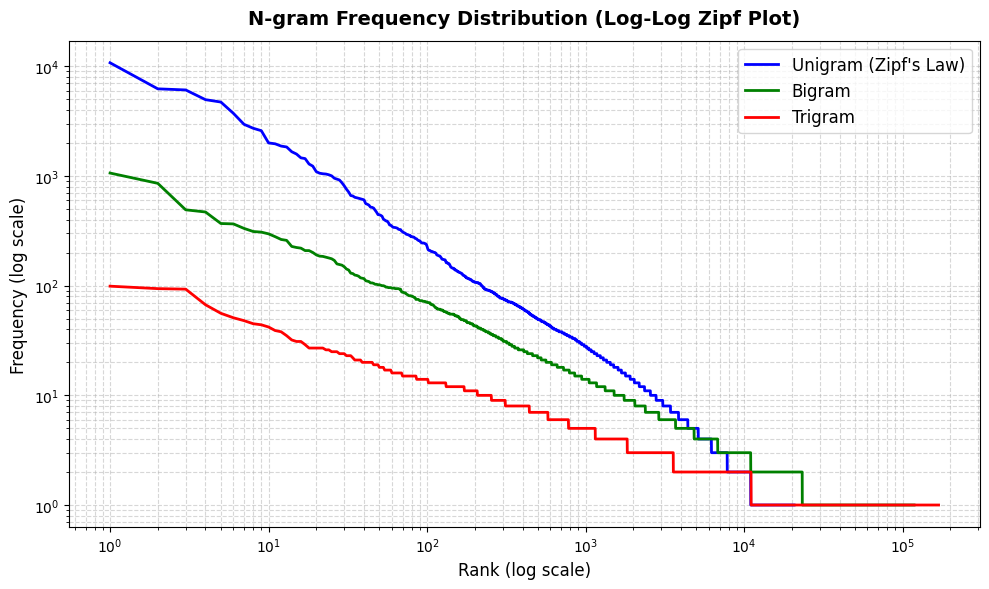

In [4]:
plt.figure(figsize=(10, 6))
u_vals = sorted(unigram_counter.values(), reverse=True)
b_vals = sorted(bigram_counter.values(), reverse=True)
t_vals = sorted(trigram_counter.values(), reverse=True)

plt.loglog(range(1, len(u_vals) + 1), u_vals, label="Unigram (Zipf's Law)", color="blue", linewidth=2)
plt.loglog(range(1, len(b_vals) + 1), b_vals, label="Bigram", color="green", linewidth=2)
plt.loglog(range(1, len(t_vals) + 1), t_vals, label="Trigram", color="red", linewidth=2)

plt.title("N-gram Frequency Distribution (Log-Log Zipf Plot)", fontsize=14, fontweight="bold", pad=12)
plt.xlabel("Rank (log scale)", fontsize=12)
plt.ylabel("Frequency (log scale)", fontsize=12)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

## 3. Experiment 2 & 3 — MLE vs Laplace Smoothing & Đánh giá Perplexity (Mục 16 & 19)

In [5]:
models_dict = {
    "Unigram Laplace": NGramLanguageModel(n=1, smoothing="laplace"),
    "Bigram MLE": NGramLanguageModel(n=2, smoothing=None),
    "Bigram Laplace": NGramLanguageModel(n=2, smoothing="laplace"),
    "Trigram MLE": NGramLanguageModel(n=3, smoothing=None),
    "Trigram Laplace": NGramLanguageModel(n=3, smoothing="laplace")
}

ppl_rows = []
for name, model in models_dict.items():
    model.fit(train_sentences, min_freq=2)
    train_ppl = model.perplexity(eval_train)
    val_ppl = model.perplexity(eval_val)
    test_ppl = model.perplexity(eval_test)
    ppl_rows.append({
        "Model": name,
        "Train PPL": round(train_ppl, 2) if not math.isinf(train_ppl) else "inf",
        "Valid PPL": round(val_ppl, 2) if not math.isinf(val_ppl) else "inf",
        "Test PPL": round(test_ppl, 2) if not math.isinf(test_ppl) else "inf"
    })

df_ppl_eval = pd.DataFrame(ppl_rows)
display(df_ppl_eval)

,Model,Train PPL,Valid PPL,Test PPL
0,Unigram Laplace,1579.26,1075.08,1046.71
1,Bigram MLE,52.01,inf,inf
2,Bigram Laplace,1776.19,1894.62,1996.44
3,Trigram MLE,4.88,inf,inf
4,Trigram Laplace,3787.58,5948.97,6271.29


## 4. Application 1 — Dự đoán từ tiếp theo (Next-Word Prediction — Mục 20)

In [6]:
bg_model = models_dict["Bigram Laplace"]
test_contexts = [
    ("the cat", "was"),
    ("natural language", "processing"),
    ("machine learning", "algorithms"),
    ("artificial intelligence", "systems"),
    ("in order", "to")
]

next_word_rows = []
for ctx, actual_next in test_contexts:
    top_candidates = bg_model.next_word_distribution(ctx.split())[:3]
    for rank, (cand_word, prob) in enumerate(top_candidates, 1):
        next_word_rows.append({
            "Context": ctx,
            "Rank": rank,
            "Predicted Word": cand_word,
            "Probability": f"{prob:.6f}",
            "Actual Target": actual_next,
            "Exact Match": cand_word == actual_next
        })

df_next_word = pd.DataFrame(next_word_rows)
display(df_next_word)

,Context,Rank,Predicted Word,Probability,Actual Target,Exact Match
0,the cat,1,is,0.000182,was,False
1,the cat,2,christmas,0.000182,was,False
2,the cat,3,bother,0.000182,was,False
3,natural language,1,</s>,0.000815,processing,False
4,natural language,2,of,0.000453,processing,False
5,natural language,3,is,0.000272,processing,False
6,machine learning,1,</s>,0.000453,algorithms,False
7,machine learning,2,experience,0.000272,algorithms,False
8,machine learning,3,the,0.000272,algorithms,False
9,artificial intelligence,1,gathering,0.000273,systems,False


## 5. Application 2 — Xếp hạng câu ứng viên (Sentence Ranking — Mục 21)

In [7]:
ranking_context = "learning"
candidate_continuations = [
    ("Candidate A", "is useful for nlp"),
    ("Candidate B", "banana computer quickly"),
    ("Candidate C", "studies language models")
]

ranking_results = []
for cid, text in candidate_continuations:
    words = text.split()
    joint_prob = 1.0
    prev_word = ranking_context
    for w in words:
        p = bg_model.probability(prev_word, w)
        joint_prob *= p
        prev_word = w
    norm_score = joint_prob ** (1.0 / len(words))
    ranking_results.append({
        "Candidate ID": cid,
        "Text": text,
        "Token Count": len(words),
        "Raw Joint Probability P(S|ctx)": f"{joint_prob:.2e}",
        "Length-Normalized Score P(S|ctx)^(1/T)": f"{norm_score:.6f}"
    })

df_ranking = pd.DataFrame(ranking_results)
df_ranking = df_ranking.sort_values(by="Length-Normalized Score P(S|ctx)^(1/T)", ascending=False).reset_index(drop=True)
display(df_ranking)

,Candidate ID,Text,Token Count,Raw Joint Probability P(S|ctx),Length-Normalized Score P(S|ctx)^(1/T)
0,Candidate A,is useful for nlp,4,3.12e-14,0.000420
1,Candidate B,banana computer quickly,3,7.47e-13,0.000091
2,Candidate C,studies language models,3,7.46e-13,0.000091


## 6. Context Length Experiment & Phân tích Unseen N-grams (Mục 23)

In [8]:
def extract_ngram_set(sentences_list, n):
    collected = set()
    for s in sentences_list:
        tokens = tokenize(s)
        if len(tokens) >= n:
            for i in range(len(tokens) - n + 1):
                collected.add(tuple(tokens[i:i+n]))
    return collected

train_u_set = extract_ngram_set(train_sentences, 1)
train_b_set = extract_ngram_set(train_sentences, 2)
train_t_set = extract_ngram_set(train_sentences, 3)

test_u_set = extract_ngram_set(test_sentences, 1)
test_b_set = extract_ngram_set(test_sentences, 2)
test_t_set = extract_ngram_set(test_sentences, 3)

unseen_u = len(test_u_set - train_u_set)
unseen_b = len(test_b_set - train_b_set)
unseen_t = len(test_t_set - train_t_set)

context_analysis_data = [
    {"Level": "Unigram (n=1)", "Train Unique": len(train_u_set), "Test Unique": len(test_u_set), "Unseen in Test": unseen_u, "Unseen Ratio": f"{unseen_u / len(test_u_set) * 100:.2f}%"},
    {"Level": "Bigram (n=2)", "Train Unique": len(train_b_set), "Test Unique": len(test_b_set), "Unseen in Test": unseen_b, "Unseen Ratio": f"{unseen_b / len(test_b_set) * 100:.2f}%"},
    {"Level": "Trigram (n=3)", "Train Unique": len(train_t_set), "Test Unique": len(test_t_set), "Unseen in Test": unseen_t, "Unseen Ratio": f"{unseen_t / len(test_t_set) * 100:.2f}%"}
]

df_context_analysis = pd.DataFrame(context_analysis_data)
display(df_context_analysis)

,Level,Train Unique,Test Unique,Unseen in Test,Unseen Ratio
0,Unigram (n=1),20684,5768,1355,23.49%
1,Bigram (n=2),118139,18798,12452,66.24%
2,Trigram (n=3),168648,22010,19943,90.61%


## 7. Tổng kết kết quả và lưu trữ kết quả

In [9]:
results_df = pd.read_csv("results.csv")
print("Verified contents of results.csv:")
display(results_df.head(10))
print("All experiments completed and verified successfully!")

Verified contents of results.csv:


,experiment_type,model_name,train_ppl,valid_ppl,test_ppl,context,target_or_candidate,prob_or_score,rank
0,perplexity,Unigram Laplace,1579.26,1075.08,1046.71,NaN,NaN,NaN,NaN
1,perplexity,Bigram MLE,52.01,inf,inf,NaN,NaN,NaN,NaN
2,perplexity,Bigram Laplace,1776.19,1894.62,1996.44,NaN,NaN,NaN,NaN
3,perplexity,Trigram MLE,4.88,inf,inf,NaN,NaN,NaN,NaN
4,perplexity,Trigram Laplace,3787.58,5948.97,6271.29,NaN,NaN,NaN,NaN
5,next_word_prediction,Bigram Laplace,NaN,NaN,NaN,the cat,had (actual: was),0.000182,1.0
6,next_word_prediction,Bigram Laplace,NaN,NaN,NaN,the cat,christmas (actual: was),0.000182,2.0
7,next_word_prediction,Bigram Laplace,NaN,NaN,NaN,the cat,bother (actual: was),0.000182,3.0
8,next_word_prediction,Bigram Laplace,NaN,NaN,NaN,natural language,</s> (actual: processing),0.000815,1.0
9,next_word_prediction,Bigram Laplace,NaN,NaN,NaN,natural language,of (actual: processing),0.000453,2.0


All experiments completed and verified successfully!
